# Multi-Terrain Evaluation Analysis

This notebook loads all CSV evaluation files for a selected approach from an experiment folder, computes metrics per terrain, and computes pooled metrics across all terrains.

Expected filename pattern:

```text
{approach}_{terrain}_{disturbance_condition}.csv
```

Example:

```text
pact_rough_payload.csv
pos_stairs_push.csv
tau_plane_none.csv
```

Set `EXP_FOLDER`, `APPROACH`, and optionally `DISTURBANCE_CONDITION` in the configuration cell below.


In [1]:
import os
import re
import ast
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed

try:
    import seaborn as sns
except ImportError:
    sns = None


## Configuration

In [2]:
# --- User settings ---
EXP_FOLDER = "exp_data_corl_10/"
APPROACH = "go1_pact"

# Set to None to load every disturbance condition for this approach.
# Otherwise use strings like "none", "payload", "push", etc.
DISTURBANCE_CONDITION = None

# Optional output directory for result tables
RESULTS_DIR = Path(EXP_FOLDER) / "analysis_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Default target used for height tracking.
BASE_HEIGHT_TARGET = 0.30

# Optional constants used only for limit violation metrics.
# Expected shapes:
#   JOINT_LIMITS: [2, num_dofs], where row 0 is lower and row 1 is upper
#   JOINT_TORQUE_LIMITS: scalar or [num_dofs]
JOINT_LIMITS = np.array([[-1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721],
                         [1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837]])
JOINT_TORQUE_LIMITS = np.array([23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55])

EPS = 1e-8

EXCLUDE_DIRS = ["analysis_results"]

NUM_WORKERS = 20

## Loading utilities

In [3]:
def string_to_array(array_string):
    """Convert stringified list/array columns from the logger into Python lists."""
    if isinstance(array_string, str):
        try:
            return ast.literal_eval(array_string)
        except (ValueError, SyntaxError):
            return array_string
    return array_string


ARRAY_COLUMNS = [
    "base_cmd",
    "base_pose",
    "base_rpy",
    "dof_pose",
    "base_lin_vel",
    "base_ang_vel",
    "dof_vel",
    "proj_grav",
    "feet_pos",
    "tau_act",
    "grf",
    "q_des",
    "tau_ff",
    "tau_pd",
    "payload",
    "com_shift",
    "rand_push",
    "rand_wrench",
]


def get_csv_converters(columns=ARRAY_COLUMNS):
    return {col: string_to_array for col in columns}


def parse_eval_filename(path, approach):
    """
    Parse filenames of the form:
        {approach}_{terrain}_{disturbance_condition}.csv

    This assumes the terrain token comes immediately after the approach token.
    Everything after the terrain token is treated as the disturbance condition.
    """
    stem = Path(path).stem

    prefix = f"{approach}_"
    if not stem.startswith(prefix):
        return None

    remainder = stem[len(prefix):]
    parts = remainder.split("_")

    if len(parts) < 2:
        return None

    terrain = parts[0]
    disturbance_condition = "_".join(parts[1:])

    return {
        "approach": approach,
        "terrain": terrain,
        "disturbance_condition": disturbance_condition,
        "path": Path(path),
    }


def find_eval_files(exp_folder, approach, disturbance_condition=None):
    exp_folder = Path(exp_folder)

    records = []
    for path in sorted(exp_folder.rglob(f"{approach}_*.csv")):
        info = parse_eval_filename(path, approach)
        if info is None:
            continue

        # Skip blacklisted subdirectories
        if EXCLUDE_DIRS:
            rel_parts = path.relative_to(exp_folder).parts
            if any(part in EXCLUDE_DIRS for part in rel_parts):
                continue

        if disturbance_condition is not None:
            if info["disturbance_condition"] != disturbance_condition:
                continue

        records.append(info)

    return pd.DataFrame(records)


def load_eval_csv(path):
    """Load one evaluation CSV with logger array columns converted."""
    return pd.read_csv(path, converters=get_csv_converters())


def load_eval_dataset(file_table):
    """
    Load all files in file_table and concatenate them into one dataframe.

    Adds:
        approach
        terrain
        disturbance_condition
        source_file
    """
    dfs = []

    for _, row in file_table.iterrows():
        df = load_eval_csv(row["path"])

        df["approach"] = row["approach"]
        df["terrain"] = row["terrain"]
        df["disturbance_condition"] = row["disturbance_condition"]
        df["source_file"] = str(row["path"])

        dfs.append(df)

    if not dfs:
        raise FileNotFoundError("No matching evaluation CSV files were found.")

    return pd.concat(dfs, ignore_index=True)


def _load_one_eval_file(row):
    df = load_eval_csv(row["path"])

    df["approach"] = row["approach"]
    df["terrain"] = row["terrain"]
    df["disturbance_condition"] = row["disturbance_condition"]
    df["source_file"] = str(row["path"])

    return df

def load_eval_dataset_parallel(file_table, max_workers=10):
    rows = [row for _, row in file_table.iterrows()]

    with ProcessPoolExecutor(max_workers=max_workers) as executor:
        dfs = list(executor.map(_load_one_eval_file, rows))

    if not dfs:
        raise FileNotFoundError("No matching evaluation CSV files were found.")

    return pd.concat(dfs, ignore_index=True)

In [4]:
file_table = find_eval_files(
    EXP_FOLDER,
    APPROACH,
    disturbance_condition=DISTURBANCE_CONDITION,
)

file_table


,approach,terrain,disturbance_condition,path
0,go1_pact,discrete,none,exp_data_corl_10/no_disturbance/go1_pact_discr...
1,go1_pact,plane,none,exp_data_corl_10/no_disturbance/go1_pact_plane...
2,go1_pact,rough,none,exp_data_corl_10/no_disturbance/go1_pact_rough...
3,go1_pact,slope,none,exp_data_corl_10/no_disturbance/go1_pact_slope...
4,go1_pact,stairs,none,exp_data_corl_10/no_disturbance/go1_pact_stair...
5,go1_pact,wave,none,exp_data_corl_10/no_disturbance/go1_pact_wave_...
6,go1_pact,discrete,payload,exp_data_corl_10/payload_disturbance/go1_pact_...
7,go1_pact,plane,payload,exp_data_corl_10/payload_disturbance/go1_pact_...
8,go1_pact,rough,payload,exp_data_corl_10/payload_disturbance/go1_pact_...
9,go1_pact,slope,payload,exp_data_corl_10/payload_disturbance/go1_pact_...


In [5]:
df_all = load_eval_dataset_parallel(file_table, max_workers=NUM_WORKERS)

print(f"Loaded {len(file_table)} files")
print(f"Loaded {len(df_all):,} rows")
print("Terrains:", sorted(df_all["terrain"].unique()))
print("Disturbance conditions:", sorted(df_all["disturbance_condition"].unique()))

df_all.head()


Loaded 18 files
Loaded 7,200,000 rows
Terrains: ['discrete', 'plane', 'rough', 'slope', 'stairs', 'wave']
Disturbance conditions: ['none', 'payload', 'push']


,Unnamed: 0,base_cmd,base_pose,base_rpy,dof_pose,base_lin_vel,base_ang_vel,dof_vel,proj_grav,feet_pos,...,tau_pd,failure,payload,com_shift,rand_push,rand_wrench,approach,terrain,disturbance_condition,source_file
0,0,"[0.0, -0.0, -0.4132351577281952, -0.8331868052...","[3.7701663970947266, 3.518017530441284, 0.3340...","[-0.009281938895583153, -0.001331201521679759,...","[0.1802046149969101, 0.9402025938034058, -1.49...","[-0.18355558812618256, -0.08572490513324738, -...","[-0.2048809975385666, -0.08853254467248917, -0...","[0.49151673913002014, 0.9893165826797485, -2.5...","[-0.0013312011724337935, 0.009281795471906662,...","[[3.8992557525634766, 3.4436283111572266, 0.01...",...,"[-8.170184135437012, -4.051390647888184, 0.222...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,exp_data_corl_10/no_disturbance/go1_pact_discr...
1,1,"[-0.6775726079940796, 0.06778740882873535, 0.6...","[20.399085998535156, 4.271790027618408, 0.3343...","[0.010541819967329502, 0.00609299773350358, -0...","[-0.12184165418148041, 0.7267966866493225, -1....","[0.40241488814353943, -0.46725377440452576, -0...","[0.7259382009506226, 0.6569470167160034, -0.61...","[0.00699186185374856, 0.3402053415775299, 2.07...","[0.006092960014939308, -0.010541427880525589, ...","[[20.604372024536133, 4.110492706298828, 0.045...",...,"[0.7676727175712585, 2.2275266647338867, 2.364...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,exp_data_corl_10/no_disturbance/go1_pact_discr...
2,2,"[0.18936622142791748, -0.07134497165679932, 1....","[27.827268600463867, 3.664759397506714, 0.3416...","[0.012672158889472485, 0.010012626647949219, 0...","[0.028530199080705643, 0.8236022591590881, -1....","[-0.13542072474956512, -0.37626221776008606, 0...","[0.7797532677650452, 0.702947735786438, 0.2935...","[-2.863589286804199, -1.2566922903060913, 3.60...","[0.010012458078563213, -0.012671183794736862, ...","[[28.008955001831055, 3.5507922172546387, 0.04...",...,"[-3.4348721504211426, -0.42817139625549316, 2....",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,exp_data_corl_10/no_disturbance/go1_pact_discr...
3,3,"[0.0, 0.0, 0.47363102436065674, 0.949077844619...","[27.70307731628418, 4.10685396194458, 0.343999...","[0.013728045858442783, -0.009996401146054268, ...","[0.10529624670743942, 0.5561085343360901, -1.5...","[0.08811206370592117, -0.2928820252418518, 0.1...","[0.7507747411727905, -0.5797853469848633, 0.17...","[-2.387899398803711, 1.9190545082092285, 3.981...","[-0.009996234439313412, -0.01372692920267582, ...","[[27.960906982421875, 4.016336441040039, 0.042...",...,"[-1.3981578350067139, 1.775514006614685, 4.213...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,exp_data_corl_10/no_disturbance/go1_pact_discr...
4,4,"[-0.8110364675521851, 0.18676280975341797, -1....","[3.5269479751586914, 4.2429118156433105, 0.336...","[0.03203384205698967, 0.0016770369838923216, -...","[0.08604538440704346, 0.9234318137168884, -1.5...","[-0.4609608054161072, -0.44092562794685364, -0...","[1.8132034540176392, 0.13724865019321442, -0.4...","[-2.430473566055298, -4.101149559020996, 5.803...","[0.001677036052569747, -0.03202832117676735, -...","[[3.671999454498291, 4.15086555480957, 0.02897...",...,"[-0.38517117500305176, -3.871809482574463, 4.2...",0,[1.0],"[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]","[0.0, 0.0, 0.0]",go1_pact,discrete,none,exp_data_corl_10/no_disturbance/go1_pact_discr...


## Metric utilities

In [6]:
def as_array(df, column, valid_mask=None):
    """Convert a dataframe column of list-like entries into a numpy array."""
    if column not in df.columns:
        return None

    series = df[column]
    if valid_mask is not None:
        series = series.loc[valid_mask]

    if len(series) == 0:
        return None

    return np.asarray(series.to_list())


def safe_mean(x):
    return float(np.nan) if x is None or len(np.asarray(x)) == 0 else float(np.nanmean(x))


def safe_std(x):
    return float(np.nan) if x is None or len(np.asarray(x)) == 0 else float(np.nanstd(x))


def rmse(x):
    x = np.asarray(x)
    return float(np.sqrt(np.nanmean(np.square(x))))


def mae(x):
    x = np.asarray(x)
    return float(np.nanmean(np.abs(x)))


def mean_norm(x, axis=1):
    x = np.asarray(x)
    return float(np.nanmean(np.linalg.norm(x, axis=axis, ord=1)))


def std_norm(x, axis=1):
    x = np.asarray(x)
    return float(np.nanstd(np.linalg.norm(x, axis=axis, ord=1)))


def rpy_to_rotmat(rpy):
    """
    rpy: (..., 3) roll, pitch, yaw
    returns: (..., 3, 3) rotation matrix (base -> world)
    """
    roll, pitch, yaw = rpy[..., 0], rpy[..., 1], rpy[..., 2]

    cr, sr = np.cos(roll),  np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw),   np.sin(yaw)

    R = np.stack([
        np.stack([cy*cp, cy*sp*sr - sy*cr, cy*sp*cr + sy*sr], axis=-1),
        np.stack([sy*cp, sy*sp*sr + cy*cr, sy*sp*cr - cy*sr], axis=-1),
        np.stack([-sp,   cp*sr,            cp*cr           ], axis=-1)
    ], axis=-2)

    return R


In [7]:
def compute_eval_metrics(
    df,
    approach='pact',
    base_height_target=0.30,
    joint_limits=None,
    joint_torque_limits=None,
    pact_metric_approaches=("pact", "abl"),
    eps=1e-8,
):
    """
    Compute scalar evaluation metrics for one dataframe.

    Failed rows are excluded from continuous metrics but counted in failure statistics.
    """
    metrics = {}

    use_pact_metrics = (
        approach is not None
        and any(k.lower() in approach.lower() for k in pact_metric_approaches)
    )

    n_total = len(df)
    failure = df["failure"].astype(float).to_numpy() if "failure" in df.columns else np.zeros(n_total)
    valid_mask = failure == 0

    metrics["num_rows_total"] = int(n_total)
    metrics["num_rows_valid"] = int(valid_mask.sum())
    metrics["num_failures"] = int(failure.sum())
    metrics["failure_rate"] = float(failure.mean()) if n_total > 0 else np.nan

    if valid_mask.sum() == 0:
        return metrics

    q_actions = as_array(df, "q_des", valid_mask)
    q_obs = as_array(df, "dof_pose", valid_mask)

    vel_cmds = as_array(df, "base_cmd", valid_mask)
    lin_vel = as_array(df, "base_lin_vel", valid_mask)
    ang_vel = as_array(df, "base_ang_vel", valid_mask)

    base_pose = as_array(df, "base_pose", valid_mask)
    proj_grav = as_array(df, "proj_grav", valid_mask)

    q_vel = as_array(df, "dof_vel", valid_mask)
    q_tau = as_array(df, "tau_act", valid_mask)

    grfs = as_array(df, "grf", valid_mask)
    ff_tau = as_array(df, "tau_ff", valid_mask)
    pd_tau = as_array(df, "tau_pd", valid_mask)

    # Joint tracking
    if q_actions is not None and q_obs is not None:
        dof_errors = q_actions - q_obs
        metrics["dof_tracking_rmse"] = rmse(dof_errors)
        metrics["dof_tracking_mae"] = mae(dof_errors)
        metrics["q_action_norm_mean"] = mean_norm(q_actions)
        metrics["q_action_norm_std"] = std_norm(q_actions)

        if joint_limits is not None:
            joint_limits = np.asarray(joint_limits)
            joint_pred_limits_error = -(q_actions - joint_limits[0, :]).clip(max=0.0)
            joint_pred_limits_error += (q_actions - joint_limits[1, :]).clip(min=0.0)
            metrics["joint_limit_violation_mean"] = float(np.mean(joint_pred_limits_error))

    # Command tracking
    if vel_cmds is not None and lin_vel is not None and ang_vel is not None:
        lin_cmd_errors = vel_cmds[:, 0:2] - lin_vel[:, 0:2]
        ang_cmd_errors = vel_cmds[:, 2] - ang_vel[:, 2]
        cmd_errs = np.concatenate((lin_cmd_errors, ang_cmd_errors[:, None]), axis=1)

        metrics["lin_cmd_rmse"] = rmse(lin_cmd_errors)
        metrics["lin_cmd_mae"] = mae(lin_cmd_errors)
        metrics["lin_cmd_std_sqroot"] = float(np.sqrt(np.std(np.square(lin_cmd_errors))))

        metrics["ang_cmd_rmse"] = rmse(ang_cmd_errors)
        metrics["ang_cmd_mae"] = mae(ang_cmd_errors)
        metrics["ang_cmd_std_sqroot"] = float(np.sqrt(np.std(np.square(ang_cmd_errors))))

        metrics["total_cmd_rmse"] = rmse(cmd_errs)
        metrics["total_cmd_mae"] = mae(cmd_errs)

    # Height / orientation / unwanted velocity
    if base_pose is not None:
        height_errors = base_height_target - base_pose[:, 2]
        metrics["height_rmse"] = rmse(height_errors)
        metrics["height_mae"] = mae(height_errors)

    if proj_grav is not None:
        orientation_norm = np.linalg.norm(proj_grav[:, 0:2], axis=1, ord=1)
        metrics["projected_gravity_rp_norm_mean"] = safe_mean(orientation_norm)
        metrics["projected_gravity_rp_norm_std"] = safe_std(orientation_norm)

    if lin_vel is not None and ang_vel is not None:
        z_vel = lin_vel[:, 2]
        ang_vel_rp_norm = np.linalg.norm(ang_vel[:, 0:2], axis=1, ord=1)
        total_unwanted_vel = np.concatenate((z_vel[:, None], ang_vel[:, 0:2]), axis=1)
        total_unwanted_norm = np.linalg.norm(total_unwanted_vel, axis=1, ord=1)

        metrics["z_vel_rmse"] = rmse(z_vel)
        metrics["z_vel_mae"] = mae(z_vel)
        metrics["ang_vel_rp_norm_mean"] = safe_mean(ang_vel_rp_norm)
        metrics["ang_vel_rp_norm_std"] = safe_std(ang_vel_rp_norm)
        metrics["total_unwanted_vel_norm_mean"] = safe_mean(total_unwanted_norm)
        metrics["total_unwanted_vel_norm_std"] = safe_std(total_unwanted_norm)

    # Torque / force / power
    if q_vel is not None and q_tau is not None:
        joint_power = q_vel * q_tau
        metrics["joint_power_norm_mean"] = mean_norm(joint_power)
        metrics["joint_power_norm_std"] = std_norm(joint_power)

    if grfs is not None:
        # Handle either [N, 4, 3] or flattened [N, 12].
        grf_flat = grfs.reshape(grfs.shape[0], -1)
        metrics["grf_norm_mean"] = mean_norm(grf_flat)
        metrics["grf_norm_std"] = std_norm(grf_flat)

    if ff_tau is not None:
        metrics["ff_tau_norm_mean"] = mean_norm(ff_tau)
        metrics["ff_tau_norm_std"] = std_norm(ff_tau)

    if pd_tau is not None:
        metrics["pd_tau_norm_mean"] = mean_norm(pd_tau)
        metrics["pd_tau_norm_std"] = std_norm(pd_tau)

    if use_pact_metrics and ff_tau is not None and pd_tau is not None:
        total_tau_cmd = ff_tau + pd_tau
        metrics["total_tau_cmd_norm_mean"] = mean_norm(total_tau_cmd)
        metrics["total_tau_cmd_norm_std"] = std_norm(total_tau_cmd)

        ff_norm = np.linalg.norm(ff_tau, axis=1)
        pd_norm = np.linalg.norm(pd_tau, axis=1)
        metrics["ff_tau_ratio_mean"] = safe_mean(ff_norm / (ff_norm + pd_norm + eps))
        metrics["pd_tau_ratio_mean"] = safe_mean(pd_norm / (ff_norm + pd_norm + eps))
        metrics["pd_to_ff_tau_norm_ratio"] = float(np.mean(pd_norm) / (np.mean(ff_norm) + eps))

        if joint_torque_limits is not None:
            joint_torque_limits = np.asarray(joint_torque_limits)
            violation = -(total_tau_cmd - (-joint_torque_limits)).clip(max=0.0)
            violation += (total_tau_cmd - joint_torque_limits).clip(min=0.0)
            metrics["joint_torque_limit_violation_mean"] = float(np.mean(violation))

    # FF/PD power interaction metrics
    if use_pact_metrics and ff_tau is not None and pd_tau is not None and q_vel is not None:
        ff_power = ff_tau * q_vel
        pd_power = pd_tau * q_vel
        total_power = (ff_tau + pd_tau) * q_vel

        dot = np.sum(ff_power * pd_power, axis=1)
        ff_power_norm = np.linalg.norm(ff_power, axis=1)
        pd_power_norm = np.linalg.norm(pd_power, axis=1)

        cosine_sim = dot / ((ff_power_norm * pd_power_norm) + eps)

        metrics["ff_power_norm_mean"] = safe_mean(ff_power_norm)
        metrics["pd_power_norm_mean"] = safe_mean(pd_power_norm)
        metrics["pd_to_ff_power_ratio"] = float(np.mean(pd_power_norm) / (np.mean(ff_power_norm) + eps))
        metrics["power_alignment_mean"] = safe_mean(cosine_sim)
        metrics["power_alignment_std"] = safe_std(cosine_sim)

        neg_dot = np.maximum(-dot, 0.0)
        metrics["fraction_antagonistic_energy"] = float(np.sum(neg_dot) / (np.sum(np.abs(dot)) + eps))

        numerator = np.abs(ff_power) + np.abs(pd_power) - np.abs(total_power)
        denominator = np.abs(ff_power) + np.abs(pd_power)
        metrics["internal_power_cancellation"] = float(np.mean(numerator) / (np.mean(denominator) + eps))

    return metrics


## Compute per-terrain and all-terrain metrics

In [8]:
def summarize_by_terrain(df_all):
    rows = []

    group_cols = ["approach", "terrain", "disturbance_condition"]
    for keys, df_group in df_all.groupby(group_cols):
        approach, terrain, disturbance_condition = keys

        metrics = compute_eval_metrics(
            df_group,
            approach=approach,
            pact_metric_approaches=("pact", "abl"),
            base_height_target=BASE_HEIGHT_TARGET,
            joint_limits=JOINT_LIMITS,
            joint_torque_limits=JOINT_TORQUE_LIMITS,
            eps=EPS,
        )

        rows.append({
            "approach": approach,
            "terrain": terrain,
            "disturbance_condition": disturbance_condition,
            **metrics,
        })

    return pd.DataFrame(rows)


def summarize_all_terrains(df_all):
    rows = []

    group_cols = ["approach", "disturbance_condition"]
    for keys, df_group in df_all.groupby(group_cols):
        approach, disturbance_condition = keys

        metrics = compute_eval_metrics(
            df_group,
            approach=approach,
            pact_metric_approaches=("pact", "abl"),
            base_height_target=BASE_HEIGHT_TARGET,
            joint_limits=JOINT_LIMITS,
            joint_torque_limits=JOINT_TORQUE_LIMITS,
            eps=EPS,
        )

        rows.append({
            "approach": approach,
            "terrain": "ALL",
            "disturbance_condition": disturbance_condition,
            **metrics,
        })

    return pd.DataFrame(rows)


per_terrain_results = summarize_by_terrain(df_all)
all_terrain_results = summarize_all_terrains(df_all)
combined_results = pd.concat([per_terrain_results, all_terrain_results], ignore_index=True)

combined_results


,approach,terrain,disturbance_condition,num_rows_total,num_rows_valid,num_failures,failure_rate,dof_tracking_rmse,dof_tracking_mae,q_action_norm_mean,...,pd_tau_ratio_mean,pd_to_ff_tau_norm_ratio,joint_torque_limit_violation_mean,ff_power_norm_mean,pd_power_norm_mean,pd_to_ff_power_ratio,power_alignment_mean,power_alignment_std,fraction_antagonistic_energy,internal_power_cancellation
0,go1_pact,discrete,none,400000,399999,1,0.000003,0.130975,0.096785,9.322908,...,0.469844,0.916504,0.000319,27.227293,34.350029,1.261603,0.762265,0.253984,0.001748,0.039526
1,go1_pact,discrete,payload,400000,399958,42,0.000105,0.155509,0.113385,9.487578,...,0.474601,0.933494,0.011736,34.341789,42.663279,1.242314,0.754354,0.271303,0.013538,0.048395
2,go1_pact,discrete,push,400000,399971,29,0.000073,0.154469,0.110287,9.311014,...,0.486616,0.992789,0.012511,40.313155,50.209399,1.245484,0.759813,0.257622,0.063282,0.052843
3,go1_pact,plane,none,400000,400000,0,0.000000,0.125855,0.094317,9.192497,...,0.464795,0.893249,0.000043,25.459294,31.996759,1.256781,0.782668,0.231206,0.000644,0.034477
4,go1_pact,plane,payload,400000,399972,28,0.000070,0.153997,0.113950,9.456269,...,0.470419,0.913102,0.008937,32.262573,38.650747,1.198006,0.775002,0.248822,0.006631,0.043277
5,go1_pact,plane,push,400000,399993,7,0.000017,0.144098,0.105016,9.181643,...,0.480519,0.962408,0.005293,35.397048,43.455071,1.227647,0.769979,0.246501,0.049311,0.045362
6,go1_pact,rough,none,400000,400000,0,0.000000,0.131501,0.097360,9.295132,...,0.472306,0.925881,0.000073,27.436439,34.469615,1.256344,0.763863,0.249298,0.001709,0.040529
7,go1_pact,rough,payload,400000,399955,45,0.000112,0.154837,0.112612,9.426257,...,0.472293,0.925896,0.011976,34.117048,41.216795,1.208100,0.750430,0.278326,0.009317,0.048010
8,go1_pact,rough,push,400000,399986,14,0.000035,0.154137,0.110457,9.332586,...,0.487543,0.995831,0.010011,39.938477,48.801854,1.221926,0.752542,0.266518,0.027844,0.053116
9,go1_pact,slope,none,400000,400000,0,0.000000,0.131917,0.097178,9.560753,...,0.466005,0.901317,0.000066,28.215004,34.967690,1.239330,0.756293,0.258599,0.001861,0.040414


In [9]:
# Save result tables
per_terrain_path = RESULTS_DIR / f"{APPROACH}_per_terrain_results.csv"
all_terrain_path = RESULTS_DIR / f"{APPROACH}_all_terrain_results.csv"
combined_path = RESULTS_DIR / f"{APPROACH}_combined_results.csv"

per_terrain_results.to_csv(per_terrain_path, index=False)
all_terrain_results.to_csv(all_terrain_path, index=False)
combined_results.to_csv(combined_path, index=False)

print("Saved:")
print(per_terrain_path)
print(all_terrain_path)
print(combined_path)


Saved:
exp_data_corl_10/analysis_results/go1_pact_per_terrain_results.csv
exp_data_corl_10/analysis_results/go1_pact_all_terrain_results.csv
exp_data_corl_10/analysis_results/go1_pact_combined_results.csv


## Compact result views

In [10]:
# Choose the metrics you care about most for a compact table.
summary_cols = [
    "approach",
    "terrain",
    "disturbance_condition",
    "num_failures",
    "height_mae",
    "lin_cmd_mae",
    "ang_cmd_mae",
    "projected_gravity_rp_norm_mean",
    "z_vel_mae",
    "ang_vel_rp_norm_mean",
    "dof_tracking_mae",
    "joint_power_norm_mean",
    "pd_to_ff_power_ratio",
    "power_alignment_mean",
    "fraction_antagonistic_energy",
    "internal_power_cancellation",
    "ff_tau_norm_mean",
    "pd_tau_norm_mean",
    "joint_torque_limit_violation_mean"
]

available_summary_cols = [c for c in summary_cols if c in combined_results.columns]

compact_results = combined_results[available_summary_cols].copy()
compact_results


,approach,terrain,disturbance_condition,num_failures,height_mae,lin_cmd_mae,ang_cmd_mae,projected_gravity_rp_norm_mean,z_vel_mae,ang_vel_rp_norm_mean,dof_tracking_mae,joint_power_norm_mean,pd_to_ff_power_ratio,power_alignment_mean,fraction_antagonistic_energy,internal_power_cancellation,ff_tau_norm_mean,pd_tau_norm_mean,joint_torque_limit_violation_mean
0,go1_pact,discrete,none,1,0.046524,0.125746,0.138600,0.079429,0.064605,0.592731,0.096785,41.683697,1.261603,0.762265,0.001748,0.039526,26.421843,25.495363,0.000319
1,go1_pact,discrete,payload,42,0.042619,0.162949,0.178868,0.112940,0.082291,0.685322,0.113385,49.439410,1.242314,0.754354,0.013538,0.048395,32.658047,31.860734,0.011736
2,go1_pact,discrete,push,29,0.046432,0.304544,0.225162,0.109184,0.109722,0.935028,0.110287,66.736140,1.245484,0.759813,0.063282,0.052843,28.877844,29.716567,0.012511
3,go1_pact,plane,none,0,0.042979,0.106680,0.110926,0.056434,0.049326,0.480527,0.094317,38.107394,1.256781,0.782668,0.000644,0.034477,25.931661,24.575092,0.000043
4,go1_pact,plane,payload,28,0.033579,0.143693,0.151312,0.094266,0.067235,0.606352,0.113950,43.790211,1.198006,0.775002,0.006631,0.043277,33.141143,31.620410,0.008937
5,go1_pact,plane,push,7,0.042958,0.290681,0.185527,0.086115,0.089944,0.804283,0.105016,57.016585,1.227647,0.769979,0.049311,0.045362,28.009373,28.128845,0.005293
6,go1_pact,rough,none,0,0.040319,0.125108,0.138470,0.082149,0.072123,0.618378,0.097360,41.445910,1.256344,0.763863,0.001709,0.040529,26.336779,25.630985,0.000073
7,go1_pact,rough,payload,45,0.033965,0.160887,0.178999,0.112682,0.088227,0.708118,0.112612,47.349128,1.208100,0.750430,0.009317,0.048010,32.626902,31.544260,0.011976
8,go1_pact,rough,push,14,0.038874,0.304137,0.229351,0.113497,0.118336,0.958153,0.110457,65.378474,1.221926,0.752542,0.027844,0.053116,28.884247,29.730645,0.010011
9,go1_pact,slope,none,0,0.373955,0.132145,0.134023,0.114816,0.066807,0.596665,0.097178,41.218221,1.239330,0.756293,0.001861,0.040414,26.841969,25.488779,0.000066


In [11]:
compact_results.round(3)

,approach,terrain,disturbance_condition,num_failures,height_mae,lin_cmd_mae,ang_cmd_mae,projected_gravity_rp_norm_mean,z_vel_mae,ang_vel_rp_norm_mean,dof_tracking_mae,joint_power_norm_mean,pd_to_ff_power_ratio,power_alignment_mean,fraction_antagonistic_energy,internal_power_cancellation,ff_tau_norm_mean,pd_tau_norm_mean,joint_torque_limit_violation_mean
0,go1_pact,discrete,none,1,0.047,0.126,0.139,0.079,0.065,0.593,0.097,41.684,1.262,0.762,0.002,0.040,26.422,25.495,0.000
1,go1_pact,discrete,payload,42,0.043,0.163,0.179,0.113,0.082,0.685,0.113,49.439,1.242,0.754,0.014,0.048,32.658,31.861,0.012
2,go1_pact,discrete,push,29,0.046,0.305,0.225,0.109,0.110,0.935,0.110,66.736,1.245,0.760,0.063,0.053,28.878,29.717,0.013
3,go1_pact,plane,none,0,0.043,0.107,0.111,0.056,0.049,0.481,0.094,38.107,1.257,0.783,0.001,0.034,25.932,24.575,0.000
4,go1_pact,plane,payload,28,0.034,0.144,0.151,0.094,0.067,0.606,0.114,43.790,1.198,0.775,0.007,0.043,33.141,31.620,0.009
5,go1_pact,plane,push,7,0.043,0.291,0.186,0.086,0.090,0.804,0.105,57.017,1.228,0.770,0.049,0.045,28.009,28.129,0.005
6,go1_pact,rough,none,0,0.040,0.125,0.138,0.082,0.072,0.618,0.097,41.446,1.256,0.764,0.002,0.041,26.337,25.631,0.000
7,go1_pact,rough,payload,45,0.034,0.161,0.179,0.113,0.088,0.708,0.113,47.349,1.208,0.750,0.009,0.048,32.627,31.544,0.012
8,go1_pact,rough,push,14,0.039,0.304,0.229,0.113,0.118,0.958,0.110,65.378,1.222,0.753,0.028,0.053,28.884,29.731,0.010
9,go1_pact,slope,none,0,0.374,0.132,0.134,0.115,0.067,0.597,0.097,41.218,1.239,0.756,0.002,0.040,26.842,25.489,0.000


## Plot selected metrics by terrain

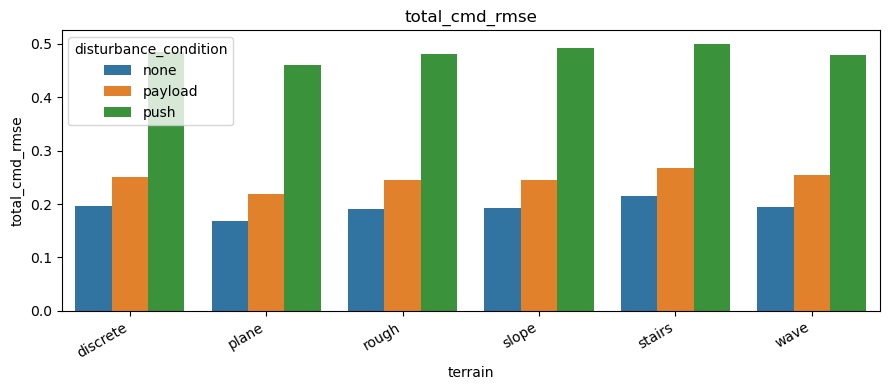

In [12]:
def plot_metric_by_terrain(results, metric, include_all=False):
    plot_df = results.copy()
    if not include_all:
        plot_df = plot_df[plot_df["terrain"] != "ALL"]

    if metric not in plot_df.columns:
        raise KeyError(f"{metric} not found in results.")

    plt.figure(figsize=(9, 4))
    if sns is not None:
        sns.barplot(data=plot_df, x="terrain", y=metric, hue="disturbance_condition")
    else:
        for condition, group in plot_df.groupby("disturbance_condition"):
            plt.bar(group["terrain"], group[metric], label=condition)
        plt.legend()

    plt.title(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


plot_metric_by_terrain(combined_results, "total_cmd_rmse")


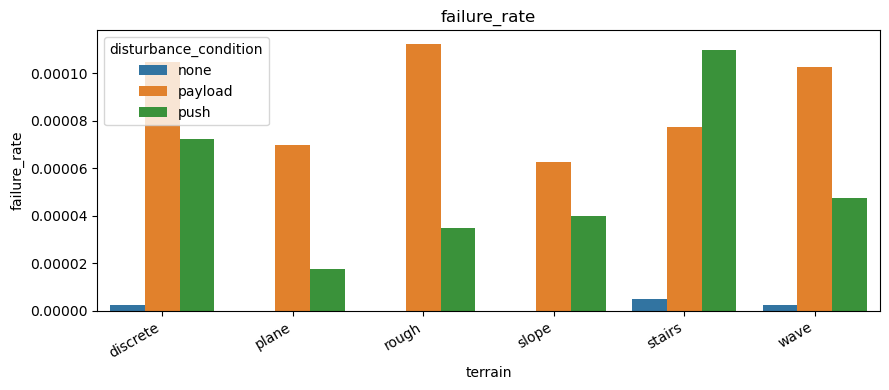

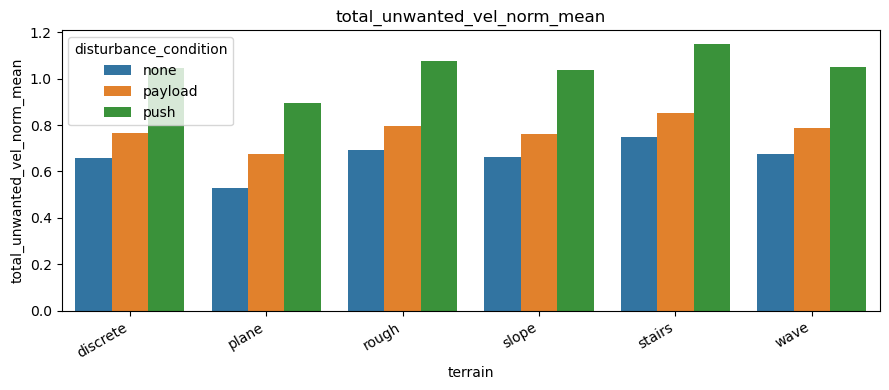

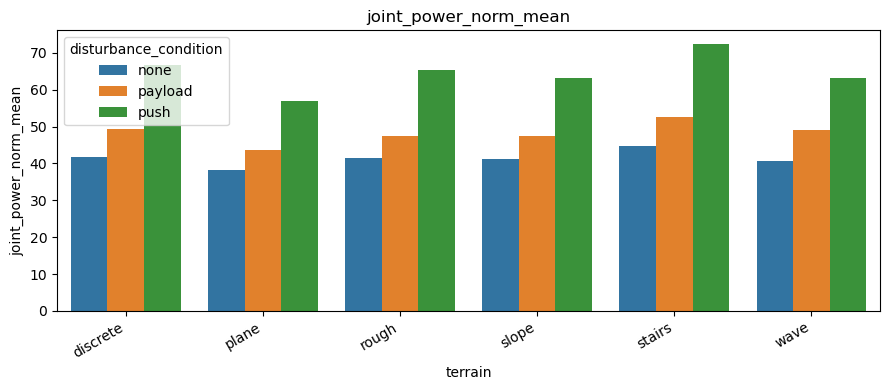

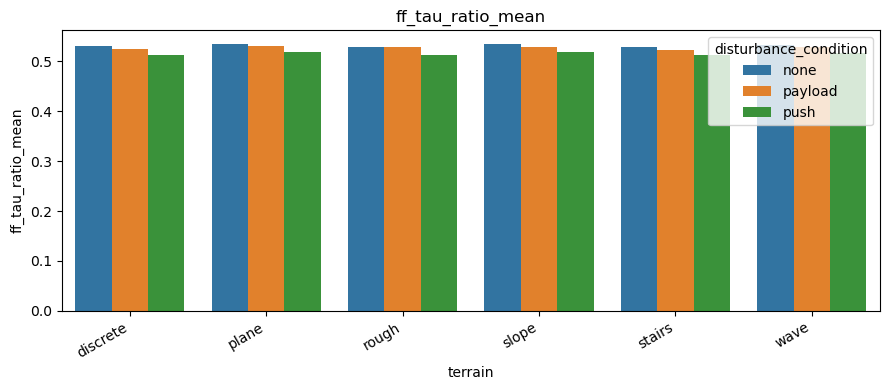

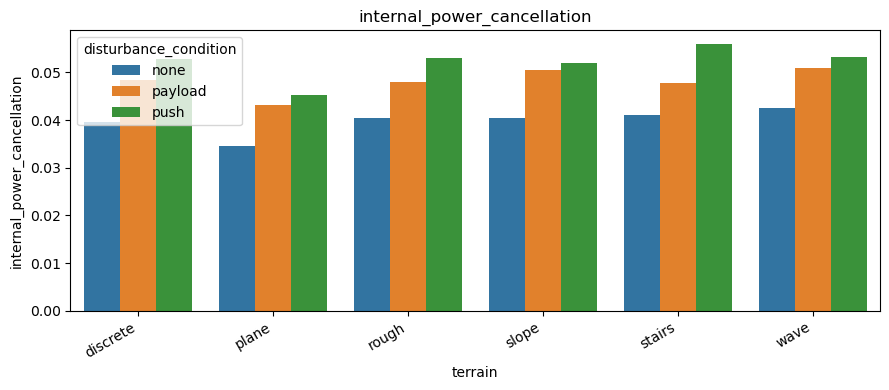

In [13]:
# Example additional plots
for metric in [
    "failure_rate",
    "total_unwanted_vel_norm_mean",
    "joint_power_norm_mean",
    "ff_tau_ratio_mean",
    "internal_power_cancellation",
]:
    if metric in combined_results.columns:
        plot_metric_by_terrain(combined_results, metric)


## Optional: compare multiple approaches

If you want to compare several approaches under the same experiment folder, set `APPROACHES` below and run the cell. It reuses the same functions above.


In [14]:
APPROACHES = ["pact"]  # e.g., ["pact", "pos", "tau"]

all_approach_dfs = []
for approach in APPROACHES:
    ft = find_eval_files(
        EXP_FOLDER,
        approach,
        disturbance_condition=DISTURBANCE_CONDITION,
    )
    if len(ft) == 0:
        print(f"No files found for approach: {approach}")
        continue

    all_approach_dfs.append(load_eval_dataset(ft))

if all_approach_dfs:
    df_multi = pd.concat(all_approach_dfs, ignore_index=True)

    multi_per_terrain = summarize_by_terrain(df_multi)
    multi_all_terrain = summarize_all_terrains(df_multi)
    multi_results = pd.concat([multi_per_terrain, multi_all_terrain], ignore_index=True)

    display(multi_results[[c for c in available_summary_cols if c in multi_results.columns]].round(4))
else:
    print("No approach files loaded.")


No files found for approach: pact
No approach files loaded.


In [15]:
def plot_metric_by_approach_and_terrain(results, metric, terrain_filter=None):
    plot_df = results.copy()

    if terrain_filter is not None:
        plot_df = plot_df[plot_df["terrain"].isin(terrain_filter)]

    if metric not in plot_df.columns:
        raise KeyError(f"{metric} not found in results.")

    plt.figure(figsize=(10, 4))
    if sns is not None:
        sns.barplot(data=plot_df, x="terrain", y=metric, hue="approach")
    else:
        for approach, group in plot_df.groupby("approach"):
            plt.bar(group["terrain"], group[metric], label=approach)
        plt.legend()

    plt.title(metric)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


if "multi_results" in globals():
    plot_metric_by_approach_and_terrain(multi_results, "total_cmd_rmse")
